In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression as lr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [7]:
data = load_breast_cancer()

In [9]:
x = data.data
y = data.target

In [11]:
x.shape

(569, 30)

In [12]:
y.shape

(569,)

In [13]:
lrl1 = lr(penalty = 'l1',solver='liblinear',C=0.5,max_iter=1000)
lrl2 = lr(penalty = 'l2',solver='liblinear',C=0.5,max_iter=1000)

In [14]:
lrl1 = lrl1.fit(x,y)

In [15]:
lrl1.coef_

array([[ 4.00594526,  0.03204039, -0.13774279, -0.01624222,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.50555346,  0.        , -0.07129889,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        , -0.24603005, -0.128702  , -0.01439708,  0.        ,
         0.        , -2.03584666,  0.        ,  0.        ,  0.        ]])

In [17]:
(lrl1.coef_ != 0).sum(axis = 1)

array([10])

In [18]:
lrl2 = lrl2.fit(x,y)
lrl2.coef_

array([[ 1.61543347e+00,  1.02277094e-01,  4.78040863e-02,
        -4.43514466e-03, -9.41951067e-02, -3.01413506e-01,
        -4.56022697e-01, -2.22299856e-01, -1.35614042e-01,
        -1.93903342e-02,  1.62178774e-02,  8.84415195e-01,
         1.20517720e-01, -9.47567759e-02, -9.81301808e-03,
        -2.37748163e-02, -5.72113404e-02, -2.70145893e-02,
        -2.77501554e-02,  1.92337530e-04,  1.26438942e+00,
        -3.01758198e-01, -1.72815374e-01, -2.21815723e-02,
        -1.73282318e-01, -8.79078818e-01, -1.16320045e+00,
        -4.27569219e-01, -4.20467759e-01, -8.69803771e-02]])

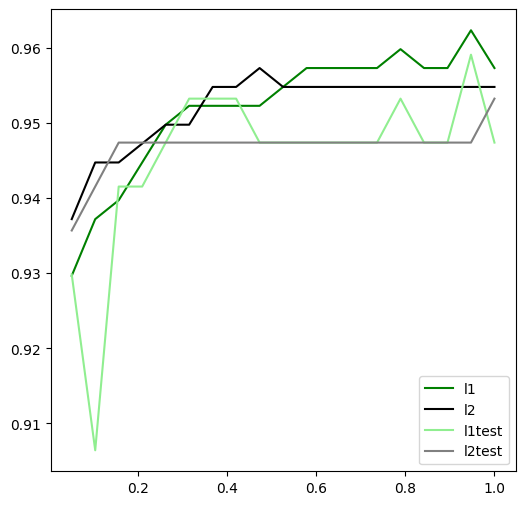

In [21]:
l1 = []
l2 = []
l1test = []
l2test = []
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.3,random_state =1 )

for i in np.linspace(0.05,1,19):
    lrl1 = lr(penalty = 'l1',solver = 'liblinear', C= i , max_iter = 1000)
    lrl2 = lr(penalty = 'l2',solver = 'liblinear', C= i , max_iter = 1000)
    lrl1 = lrl1.fit(xtrain,ytrain)
    l1.append(accuracy_score(lrl1.predict(xtrain),ytrain))
    l1test.append(accuracy_score(lrl1.predict(xtest),ytest))
    lrl2 = lrl2.fit(xtrain,ytrain)
    l2.append(accuracy_score(lrl2.predict(xtrain),ytrain))
    l2test.append(accuracy_score(lrl2.predict(xtest),ytest))
graph = [l1,l2,l1test,l2test]
color = ['green','black','lightgreen','gray']
label = ['l1','l2','l1test','l2test']

plt.figure(figsize= (6,6))
for i in range(len(graph)):
    plt.plot(np.linspace(0.05,1,19),graph[i],color[i],label=label[i])
plt.legend(loc=4)
plt.show()